# EDA: сравнение оригинального train и синтетических данных

**Цель ноутбука** — проверить, насколько синтетические объекты похожи на исходную обучающую выборку **до добавления синтетики**.

Сравниваем две таблицы отдельно:

- `train_original_before_synthetic.csv` — оригинальный train;
- `synthetic_objects_geo_enriched.csv` — отдельно сгенерированные синтетические объекты.

Основные вопросы:

1. Совпадают ли схемы, типы и пропуски?
2. Насколько похожи числовые распределения?
3. Сохранились ли категориальные пропорции?
4. Не просела ли вариативность синтетики?
5. Сохранились ли корреляции между признаками?
6. Есть ли дубли и нарушения бизнес-правил?
7. Может ли модель легко отличить оригинал от синтетики?

In [76]:
# Базовые импорты
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, chi2_contingency, wasserstein_distance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

## 1. Загрузка данных

Код ниже сначала ищет файлы рядом с ноутбуком. Если их там нет, используется путь `/mnt/data`, чтобы ноутбук сразу работал в текущем окружении.

In [77]:
NOTEBOOK_DIR = Path.cwd()
FALLBACK_DIR = Path("/mnt/data")

orig_path = NOTEBOOK_DIR / "train_original_before_synthetic_v3.csv"
synth_path = NOTEBOOK_DIR / "synthetic_objects_geo_enriched_v3.csv"

if not orig_path.exists():
    orig_path = FALLBACK_DIR / "train_original_before_synthetic_v3.csv"
if not synth_path.exists():
    synth_path = FALLBACK_DIR / "synthetic_objects_geo_enriched_v3.csv"

orig = pd.read_csv(orig_path)
synth = pd.read_csv(synth_path)

print("Original train:", orig.shape)
print("Synthetic:", synth.shape)
print("Synthetic / original ratio:", round(len(synth) / len(orig), 2))

Original train: (2068, 40)
Synthetic: (4136, 40)
Synthetic / original ratio: 2.0


In [78]:
# Быстрый просмотр
orig.head(3)

,source_group,price,area_total,rooms,floor,floors_total,address,latitude,longitude,metro,metro_walk_min,kitchen_area,renovation,walls,build_year,ceiling_height,floor_position,elevator,house_number,yard,parking,playground,link,address_source,metro_distance_km,metro_source,distance_to_center_km,distance_to_mkad_km,distance_to_school_km,distance_to_kindergarten_km,distance_to_clinic_km,distance_to_mall_km,price_per_m2,floor_ratio,house_age,has_metro_near,geo_generation_cluster,is_synthetic,generation_method,parent_geo_cluster
0,3k,"44,500,000.0000",107.0000,3.0000,6.0000,24.0000,"москва, ул. чертановская, 43к4 (14 км до центра)",55.6084,37.5933,Пражская,8.0000,16.0000,евроремонт,монолитные,"2,002.0000",2.6800,не угловая,"пассажирский, грузовой",43к4,двор,наземный паркинг,нет,https://msk.etagi.com/realty/11993775/,raw,0.6400,geo_recomputed,16.0500,3.2900,0.2500,0.2300,0.9600,0.0400,"415,887.8505",0.2500,24.0000,1,13,0,original,13
1,1k,"10,000,000.0000",34.0000,1.0000,7.0000,9.0000,"москва, ул. реутовская, 2",55.7423,37.8336,Новогиреево,12.0000,9.0000,косметический ремонт,панельные,"2,002.0000",2.6800,не угловая,unknown,2,детская площадка,unknown,нет,https://msk.etagi.com/realty/12502657/,raw,0.9900,geo_recomputed,13.6900,0.5000,0.1200,0.2400,0.4300,0.3800,"294,117.6471",0.7778,24.0000,1,24,0,original,24
2,all,"12,450,000.0000",36.6000,1.0000,3.0000,20.0000,"арм-строй, скандинавский бульвар, скандинавия,...",55.5616,37.5022,Потапово,15.0000,12.0000,черновая отделка,монолитные,"2,002.0000",2.6800,не угловая,unknown,2,unknown,unknown,нет,https://msk.etagi.com/realty/10956427/,geo,1.2300,geo_recomputed,22.3600,3.7200,0.4700,0.2200,0.6200,0.3300,"340,163.9344",0.1500,24.0000,1,8,0,original,8


In [79]:
synth.head(3)

,source_group,price,area_total,rooms,floor,floors_total,address,latitude,longitude,metro,metro_walk_min,kitchen_area,renovation,walls,build_year,ceiling_height,floor_position,elevator,house_number,yard,parking,playground,link,address_source,metro_distance_km,metro_source,distance_to_center_km,distance_to_mkad_km,distance_to_school_km,distance_to_kindergarten_km,distance_to_clinic_km,distance_to_mall_km,price_per_m2,floor_ratio,house_age,has_metro_near,geo_generation_cluster,is_synthetic,generation_method,parent_geo_cluster
0,all,"68,627,500.7768",79.8789,3,29,52,"Ozon, 56, Мичуринский проспект, Кинематографич...",55.6959,37.4850,Мичуринский проспект,9,18.9440,unknown,монолитные,2002,2.7300,не угловая,"пассажирский, грузовой, пассажирский и грузовой",NaN,двор,"подземный паркинг, наземный паркинг",нет,synthetic,geo,0.7900,geo_recomputed,10.3000,4.5000,0.3800,0.3600,0.1500,0.4500,"859,144.0887",0.5577,24.0000,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
1,2k,"28,160,109.9884",55.8519,2,10,17,"93 к2, Рублёвское шоссе (дублёр), район Кунцев...",55.7399,37.4257,Молодежная,8,11.5476,unknown,панельные,2011,2.6800,не угловая,"пассажирский, грузовой",NaN,двор,наземный паркинг,есть,synthetic,geo,0.6500,geo_recomputed,11.9600,3.2000,0.3300,0.1400,0.3200,0.2400,"504,192.5201",0.5882,15.0000,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
2,all-mozhaiskii,"44,376,800.2528",93.7398,3,5,5,"Нежинская улица, Жилой комплекс «Нежинский Ков...",55.7075,37.4701,Матвеевское,10,12.0276,требует ремонта / частичный ремонт,кирпичные,2002,3.1000,не угловая,"пассажирский, грузовой",NaN,двор,"наземный паркинг, подземный паркинг, гостевой ...",есть,synthetic,geo,0.8200,geo_recomputed,10.3700,4.0400,0.2700,0.1400,0.7600,0.0800,"473,403.8495",1.0000,24.0000,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0


## 2. Проверка схемы и типов

In [80]:
orig_cols = set(orig.columns)
synth_cols = set(synth.columns)

schema_report = pd.DataFrame({
    "metric": [
        "columns_in_original",
        "columns_in_synthetic",
        "common_columns",
        "only_in_original",
        "only_in_synthetic",
    ],
    "value": [
        len(orig_cols),
        len(synth_cols),
        len(orig_cols & synth_cols),
        sorted(orig_cols - synth_cols),
        sorted(synth_cols - orig_cols),
    ]
})
schema_report

,metric,value
0,columns_in_original,40
1,columns_in_synthetic,40
2,common_columns,40
3,only_in_original,[]
4,only_in_synthetic,[]


In [81]:
dtype_compare = pd.DataFrame({
    "original_dtype": orig.dtypes.astype(str),
    "synthetic_dtype": synth.dtypes.astype(str),
})
dtype_compare["same_dtype"] = dtype_compare["original_dtype"] == dtype_compare["synthetic_dtype"]
dtype_compare.sort_values(["same_dtype", "original_dtype"])

,original_dtype,synthetic_dtype,same_dtype
rooms,float64,int64,False
floor,float64,int64,False
floors_total,float64,int64,False
metro_walk_min,float64,int64,False
build_year,float64,int64,False
house_number,object,float64,False
price,float64,float64,True
area_total,float64,float64,True
latitude,float64,float64,True
longitude,float64,float64,True


## 3. Пропуски

Сравниваем долю пропусков в оригинале и синтетике. Сильные расхождения в пропусках — отдельный сигнал, что генерация изменила структуру данных.

In [82]:
missing = pd.DataFrame({
    "missing_original_%": orig.isna().mean() * 100,
    "missing_synthetic_%": synth.isna().mean() * 100,
})
missing["delta_pp"] = missing["missing_synthetic_%"] - missing["missing_original_%"]
missing.sort_values("delta_pp", key=lambda s: s.abs(), ascending=False).head(30)

,missing_original_%,missing_synthetic_%,delta_pp
house_number,0.0000,100.0000,100.0000
source_group,0.0000,0.0000,0.0000
area_total,0.0000,0.0000,0.0000
price,0.0000,0.0000,0.0000
floor,0.0000,0.0000,0.0000
floors_total,0.0000,0.0000,0.0000
address,0.0000,0.0000,0.0000
rooms,0.0000,0.0000,0.0000
latitude,0.0000,0.0000,0.0000
longitude,0.0000,0.0000,0.0000


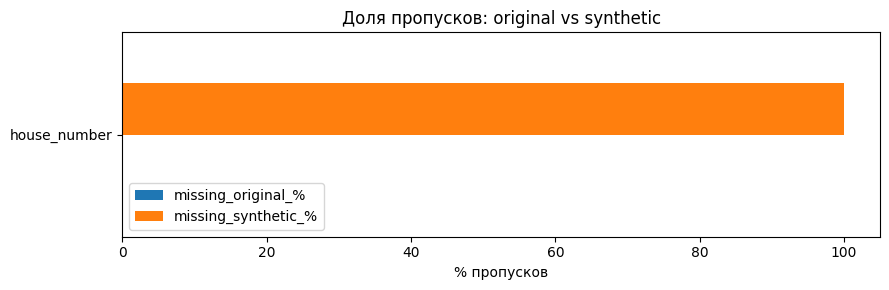

In [83]:
# Визуализация пропусков по колонкам, где есть хотя бы один пропуск
miss_plot = missing[(missing["missing_original_%"] > 0) | (missing["missing_synthetic_%"] > 0)].copy()
miss_plot = miss_plot.sort_values("delta_pp", key=lambda s: s.abs(), ascending=True)

if len(miss_plot) > 0:
    ax = miss_plot[["missing_original_%", "missing_synthetic_%"]].plot(kind="barh", figsize=(9, max(3, len(miss_plot) * 0.35)))
    ax.set_title("Доля пропусков: original vs synthetic")
    ax.set_xlabel("% пропусков")
    plt.tight_layout()
else:
    print("Пропусков нет ни в одной колонке.")

## 4. Разделение признаков

Исключаем технические признаки, которые напрямую выдают происхождение объекта или являются ссылками/адресами.

In [84]:
technical_cols = {
    "is_synthetic", "generation_method", "link", "address", "house_number"
}

common_cols = [c for c in orig.columns if c in synth.columns]
numeric_cols = [c for c in common_cols
                if c not in technical_cols and pd.api.types.is_numeric_dtype(orig[c]) and pd.api.types.is_numeric_dtype(synth[c])]

categorical_cols = [c for c in common_cols
                    if c not in technical_cols and c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)
print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

Numeric columns: 24
['price', 'area_total', 'rooms', 'floor', 'floors_total', 'latitude', 'longitude', 'metro_walk_min', 'kitchen_area', 'build_year', 'ceiling_height', 'metro_distance_km', 'distance_to_center_km', 'distance_to_mkad_km', 'distance_to_school_km', 'distance_to_kindergarten_km', 'distance_to_clinic_km', 'distance_to_mall_km', 'price_per_m2', 'floor_ratio', 'house_age', 'has_metro_near', 'geo_generation_cluster', 'parent_geo_cluster']

Categorical columns: 11
['source_group', 'metro', 'renovation', 'walls', 'floor_position', 'elevator', 'yard', 'parking', 'playground', 'address_source', 'metro_source']


## 5. Числовые признаки: сводная статистика

Смотрим не только среднее, но и стандартное отклонение, медиану, IQR и расстояния между распределениями.

Интерпретация:

- `mean_delta_%` около 0 — средние похожи;
- `std_delta_% < 0` — синтетика менее вариативна, распределение сжато;
- `ks_pvalue < 0.05` — распределения статистически различаются;
- `wasserstein_norm` — нормированное расстояние между распределениями: чем меньше, тем лучше.

In [85]:
def safe_pct_delta(synth_value, orig_value):
    if pd.isna(orig_value) or np.isclose(orig_value, 0):
        return np.nan
    return (synth_value - orig_value) / abs(orig_value) * 100

rows = []
for col in numeric_cols:
    o = orig[col].dropna()
    s = synth[col].dropna()
    if len(o) == 0 or len(s) == 0:
        continue
    ks = ks_2samp(o, s)
    scale = o.quantile(0.75) - o.quantile(0.25)
    if np.isclose(scale, 0):
        scale = o.std()
    wdist = wasserstein_distance(o, s)
    rows.append({
        "feature": col,
        "orig_mean": o.mean(),
        "synth_mean": s.mean(),
        "mean_delta_%": safe_pct_delta(s.mean(), o.mean()),
        "orig_median": o.median(),
        "synth_median": s.median(),
        "median_delta_%": safe_pct_delta(s.median(), o.median()),
        "orig_std": o.std(),
        "synth_std": s.std(),
        "std_delta_%": safe_pct_delta(s.std(), o.std()),
        "orig_iqr": o.quantile(0.75) - o.quantile(0.25),
        "synth_iqr": s.quantile(0.75) - s.quantile(0.25),
        "iqr_delta_%": safe_pct_delta(s.quantile(0.75) - s.quantile(0.25), o.quantile(0.75) - o.quantile(0.25)),
        "ks_stat": ks.statistic,
        "ks_pvalue": ks.pvalue,
        "wasserstein": wdist,
        "wasserstein_norm": wdist / scale if not np.isclose(scale, 0) else np.nan,
        "orig_missing_%": orig[col].isna().mean() * 100,
        "synth_missing_%": synth[col].isna().mean() * 100,
    })

num_compare = pd.DataFrame(rows).sort_values("ks_stat", ascending=False)
num_compare

,feature,orig_mean,synth_mean,mean_delta_%,orig_median,synth_median,median_delta_%,orig_std,synth_std,std_delta_%,orig_iqr,synth_iqr,iqr_delta_%,ks_stat,ks_pvalue,wasserstein,wasserstein_norm,orig_missing_%,synth_missing_%
8,kitchen_area,11.3343,11.2542,-0.7072,10.0000,9.6047,-3.9531,6.9013,6.8366,-0.9383,6.0000,5.7698,-3.8362,0.0721,0.0000,0.2118,0.0353,0.0000,0.0000
9,build_year,"1,997.8216","1,996.6576",-0.0583,"2,002.0000","2,002.0000",0.0000,20.9315,20.6261,-1.4590,12.2500,19.0000,55.1020,0.0532,0.0008,1.3646,0.1114,0.0000,0.0000
20,house_age,28.1784,29.3424,4.1306,24.0000,24.0000,0.0000,20.9315,20.6261,-1.4590,12.2500,19.0000,55.1020,0.0532,0.0008,1.3646,0.1114,0.0000,0.0000
15,distance_to_kindergarten_km,0.3359,0.3502,4.2448,0.2500,0.2600,4.0000,0.3914,0.3669,-6.2657,0.2500,0.2700,8.0000,0.0433,0.0113,0.0201,0.0803,0.0000,0.0000
4,floors_total,18.0106,17.7159,-1.6364,16.0000,16.0000,0.0000,10.8356,10.8012,-0.3175,15.0000,14.0000,-6.6667,0.0288,0.2026,0.3262,0.0217,0.0000,0.0000
10,ceiling_height,2.7516,2.7507,-0.0351,2.6800,2.6800,0.0000,0.2526,0.2462,-2.5087,0.0600,0.0600,0.0000,0.0288,0.2026,0.0036,0.0600,0.0000,0.0000
1,area_total,54.5386,55.2775,1.3549,48.0500,49.3624,2.7313,29.7528,30.5047,2.5272,28.8250,31.4289,9.0335,0.0247,0.3695,1.1111,0.0385,0.0000,0.0000
0,price,"25,278,110.4367","25,497,342.2927",0.8673,"19,000,000.0000","19,010,878.4866",0.0573,"21,941,942.2675","21,318,762.0674",-2.8401,"13,650,000.0000","14,671,944.7364",7.4868,0.0218,0.5289,"846,601.3842",0.0620,0.0000,0.0000
14,distance_to_school_km,0.3859,0.3949,2.3309,0.3100,0.3100,0.0000,0.3765,0.3643,-3.2226,0.2800,0.2900,3.5714,0.0210,0.5729,0.0139,0.0496,0.0000,0.0000
18,price_per_m2,"456,165.6666","454,537.9065",-0.3568,"420,662.2879","420,515.4772",-0.0349,"187,256.6544","178,159.5054",-4.8581,"181,749.8092","188,670.1836",3.8076,0.0193,0.6784,"8,724.4728",0.0480,0.0000,0.0000


In [86]:
# Топ признаков, где синтетика сильнее всего отличается по KS-статистике
num_compare[["feature", "ks_stat", "ks_pvalue", "mean_delta_%", "std_delta_%", "iqr_delta_%", "wasserstein_norm"]].head(15)

,feature,ks_stat,ks_pvalue,mean_delta_%,std_delta_%,iqr_delta_%,wasserstein_norm
8,kitchen_area,0.0721,0.0000,-0.7072,-0.9383,-3.8362,0.0353
9,build_year,0.0532,0.0008,-0.0583,-1.4590,55.1020,0.1114
20,house_age,0.0532,0.0008,4.1306,-1.4590,55.1020,0.1114
15,distance_to_kindergarten_km,0.0433,0.0113,4.2448,-6.2657,8.0000,0.0803
4,floors_total,0.0288,0.2026,-1.6364,-0.3175,-6.6667,0.0217
10,ceiling_height,0.0288,0.2026,-0.0351,-2.5087,0.0000,0.0600
1,area_total,0.0247,0.3695,1.3549,2.5272,9.0335,0.0385
0,price,0.0218,0.5289,0.8673,-2.8401,7.4868,0.0620
14,distance_to_school_km,0.0210,0.5729,2.3309,-3.2226,3.5714,0.0496
18,price_per_m2,0.0193,0.6784,-0.3568,-4.8581,3.8076,0.0480


In [87]:
# Признаки, где сильнее всего изменилась вариативность
num_compare[["feature", "orig_std", "synth_std", "std_delta_%", "orig_iqr", "synth_iqr", "iqr_delta_%"]] \
    .assign(abs_std_delta=lambda d: d["std_delta_%"].abs()) \
    .sort_values("abs_std_delta", ascending=False) \
    .drop(columns="abs_std_delta") \
    .head(20)

,feature,orig_std,synth_std,std_delta_%,orig_iqr,synth_iqr,iqr_delta_%
15,distance_to_kindergarten_km,0.3914,0.3669,-6.2657,0.2500,0.2700,8.0000
17,distance_to_mall_km,0.4175,0.3917,-6.1729,0.2800,0.2800,0.0000
16,distance_to_clinic_km,0.4990,0.4724,-5.3411,0.3900,0.3900,0.0000
18,price_per_m2,"187,256.6544","178,159.5054",-4.8581,"181,749.8092","188,670.1836",3.8076
14,distance_to_school_km,0.3765,0.3643,-3.2226,0.2800,0.2900,3.5714
0,price,"21,941,942.2675","21,318,762.0674",-2.8401,"13,650,000.0000","14,671,944.7364",7.4868
1,area_total,29.7528,30.5047,2.5272,28.8250,31.4289,9.0335
10,ceiling_height,0.2526,0.2462,-2.5087,0.0600,0.0600,0.0000
9,build_year,20.9315,20.6261,-1.4590,12.2500,19.0000,55.1020
20,house_age,20.9315,20.6261,-1.4590,12.2500,19.0000,55.1020


## 6. Квантили и хвосты распределений

Эта секция особенно важна для недвижимости: модель должна видеть не только типичные квартиры, но и дорогие/дешёвые, маленькие/большие, старые/новые объекты.

In [88]:
key_numeric = [
    "price", "price_per_m2", "area_total", "rooms", "kitchen_area",
    "floor", "floors_total", "build_year", "ceiling_height",
    "latitude", "longitude", "distance_to_center_km", "distance_to_mkad_km",
    "metro_distance_km", "distance_to_school_km", "distance_to_kindergarten_km",
    "distance_to_clinic_km", "distance_to_mall_km"
]
key_numeric = [c for c in key_numeric if c in numeric_cols]

quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
quantile_tables = {}
for col in key_numeric:
    qt = pd.DataFrame({
        "original": orig[col].quantile(quantiles),
        "synthetic": synth[col].quantile(quantiles),
    })
    qt["delta"] = qt["synthetic"] - qt["original"]
    qt["delta_%"] = np.where(qt["original"].abs() > 1e-9, qt["delta"] / qt["original"].abs() * 100, np.nan)
    quantile_tables[col] = qt

# Пример для цены и площади
quantile_tables["price"] if "price" in quantile_tables else None

,original,synthetic,delta,delta_%
0.0100,"4,500,000.0000","4,590,866.5250","90,866.5250",2.0193
0.0500,"8,300,000.0000","7,371,768.6484","-928,231.3516",-11.1835
0.2500,"14,350,000.0000","14,054,604.7414","-295,395.2586",-2.0585
0.5000,"19,000,000.0000","19,010,878.4866","10,878.4866",0.0573
0.7500,"28,000,000.0000","28,726,549.4778","726,549.4778",2.5948
0.9500,"58,325,000.0000","63,536,386.7147","5,211,386.7147",8.9351
0.9900,"120,000,000.0000","120,134,247.8220","134,247.8220",0.1119


In [89]:
# Вывод всех квантильных таблиц по ключевым признакам
for col, table in quantile_tables.items():
    print("\n" + "="*80)
    print(col)
    display(table)


price


,original,synthetic,delta,delta_%
0.0100,"4,500,000.0000","4,590,866.5250","90,866.5250",2.0193
0.0500,"8,300,000.0000","7,371,768.6484","-928,231.3516",-11.1835
0.2500,"14,350,000.0000","14,054,604.7414","-295,395.2586",-2.0585
0.5000,"19,000,000.0000","19,010,878.4866","10,878.4866",0.0573
0.7500,"28,000,000.0000","28,726,549.4778","726,549.4778",2.5948
0.9500,"58,325,000.0000","63,536,386.7147","5,211,386.7147",8.9351
0.9900,"120,000,000.0000","120,134,247.8220","134,247.8220",0.1119



price_per_m2


,original,synthetic,delta,delta_%
0.0100,"95,997.4160","83,006.7227","-12,990.6933",-13.5323
0.0500,"253,879.1594","241,070.8279","-12,808.3315",-5.0451
0.2500,"347,409.9406","343,766.3341","-3,643.6065",-1.0488
0.5000,"420,662.2879","420,515.4772",-146.8107,-0.0349
0.7500,"529,159.7498","532,436.5177","3,276.7679",0.6192
0.9500,"761,044.6158","791,337.8338","30,293.2180",3.9805
0.9900,"1,094,311.5942","1,112,583.0119","18,271.4177",1.6697



area_total


...

,original,synthetic,delta,delta_%
0.0100,0.0500,0.0300,-0.0200,-40.0000
0.0500,0.0800,0.0700,-0.0100,-12.5000
0.2500,0.1500,0.1600,0.0100,6.6667
0.5000,0.2500,0.2600,0.0100,4.0000
0.7500,0.4000,0.4300,0.0300,7.5000
0.9500,0.8400,0.8500,0.0100,1.1905
0.9900,1.7300,1.7165,-0.0135,-0.7803



distance_to_clinic_km


,original,synthetic,delta,delta_%
0.0100,0.0200,0.0400,0.0200,100.0000
0.0500,0.0900,0.0900,0.0000,0.0000
0.2500,0.2300,0.2300,0.0000,0.0000
0.5000,0.3900,0.3900,0.0000,0.0000
0.7500,0.6200,0.6200,0.0000,0.0000
0.9500,1.3600,1.3300,-0.0300,-2.2059
0.9900,2.0565,2.0500,-0.0065,-0.3161



distance_to_mall_km


,original,synthetic,delta,delta_%
0.0100,0.0400,0.0300,-0.0100,-25.0000
0.0500,0.0700,0.0700,0.0000,0.0000
0.2500,0.1600,0.1600,0.0000,0.0000
0.5000,0.2600,0.2600,0.0000,0.0000
0.7500,0.4400,0.4400,0.0000,0.0000
0.9500,1.0665,1.0325,-0.0340,-3.1880
0.9900,2.0300,1.8025,-0.2275,-11.2069


## 7. Гистограммы распределений

На графиках важны:

- сдвиг центра;
- сжатие/растяжение;
- потеря хвостов;
- искусственные пики.

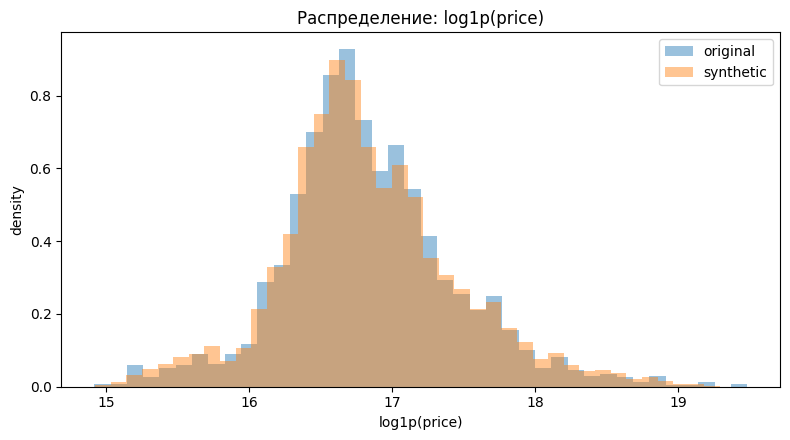

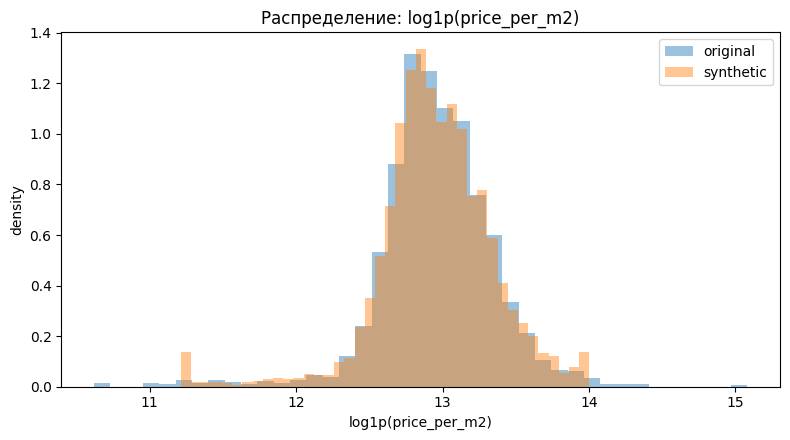

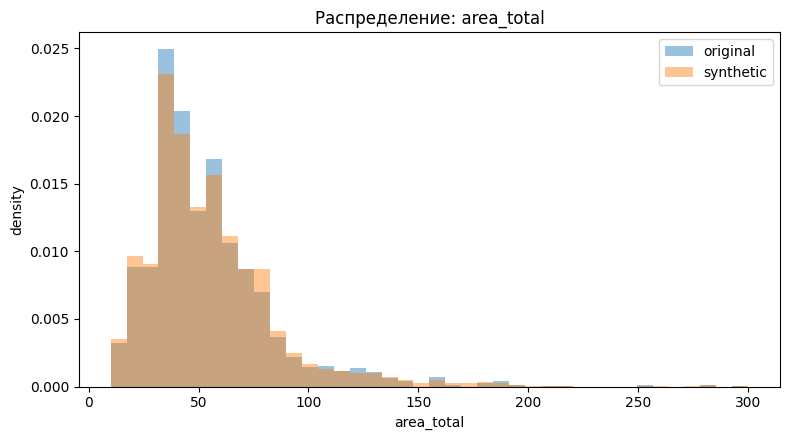

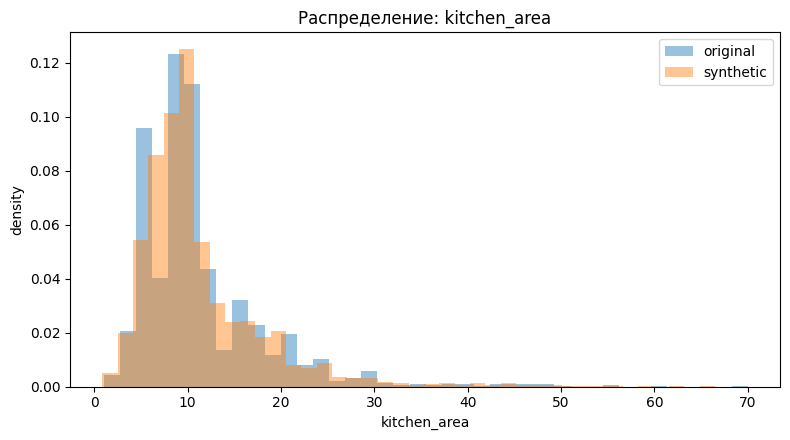

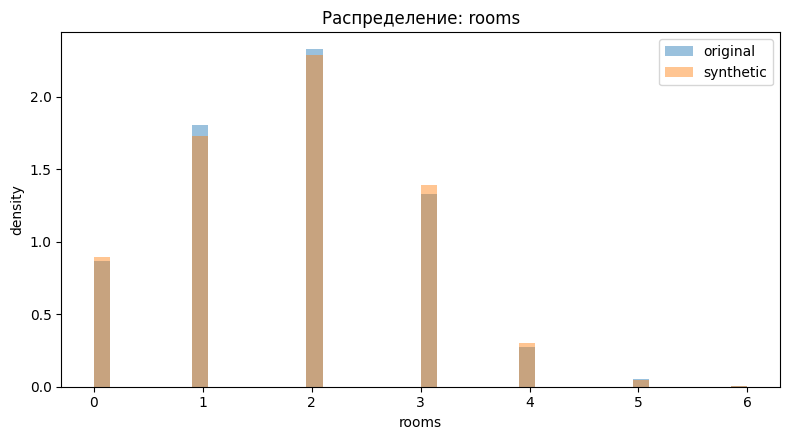

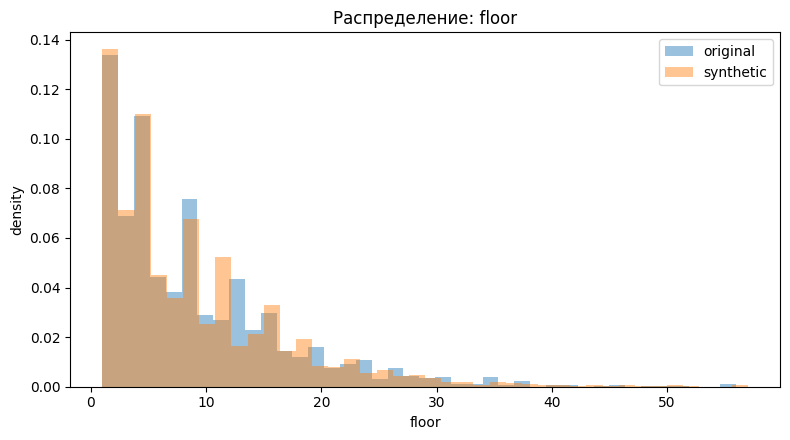

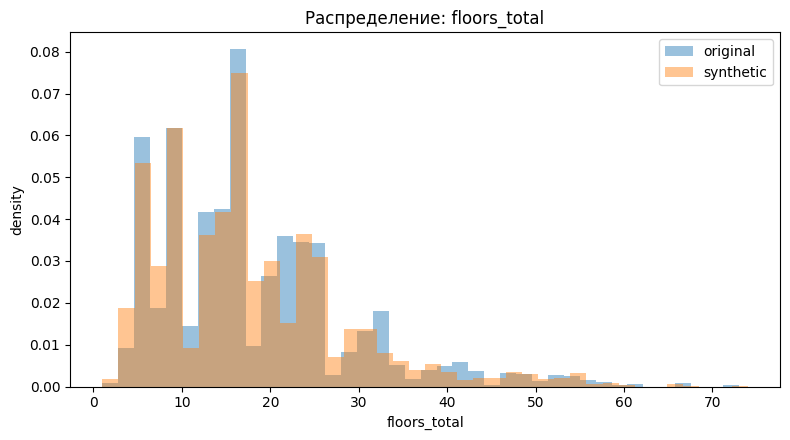

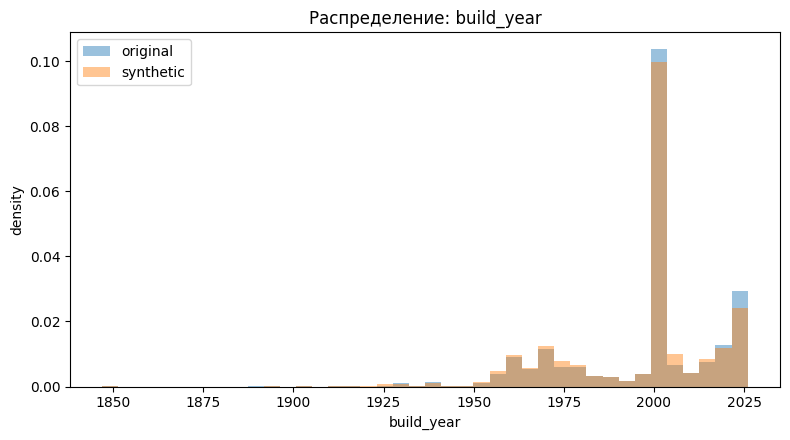

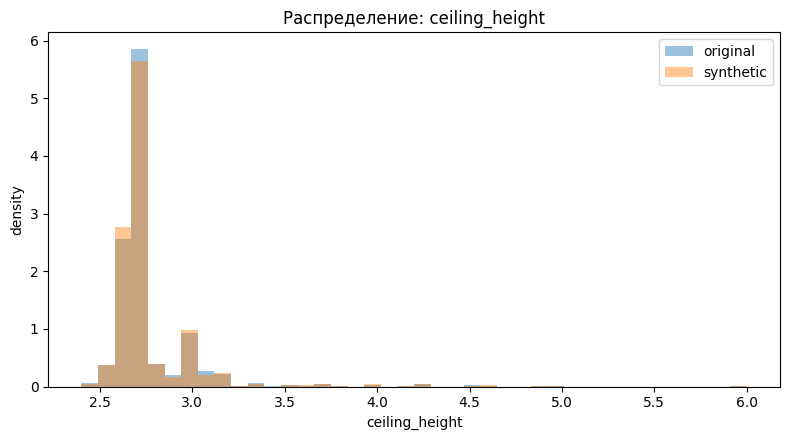

In [90]:
def plot_hist_compare(col, bins=40, log_x=False):
    o = orig[col].dropna()
    s = synth[col].dropna()
    if len(o) == 0 or len(s) == 0:
        print(f"Нет данных для {col}")
        return

    plt.figure(figsize=(8, 4.5))
    if log_x:
        o = o[o > 0]
        s = s[s > 0]
        o = np.log1p(o)
        s = np.log1p(s)
        xlabel = f"log1p({col})"
    else:
        xlabel = col

    plt.hist(o, bins=bins, density=True, alpha=0.45, label="original")
    plt.hist(s, bins=bins, density=True, alpha=0.45, label="synthetic")
    plt.title(f"Распределение: {xlabel}")
    plt.xlabel(xlabel)
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()

for col in ["price", "price_per_m2", "area_total", "kitchen_area", "rooms", "floor", "floors_total", "build_year", "ceiling_height"]:
    if col in key_numeric:
        plot_hist_compare(col, log_x=col in ["price", "price_per_m2"])

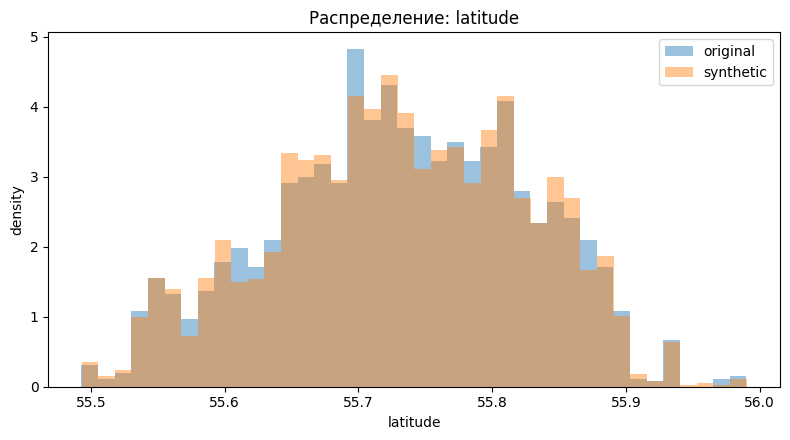

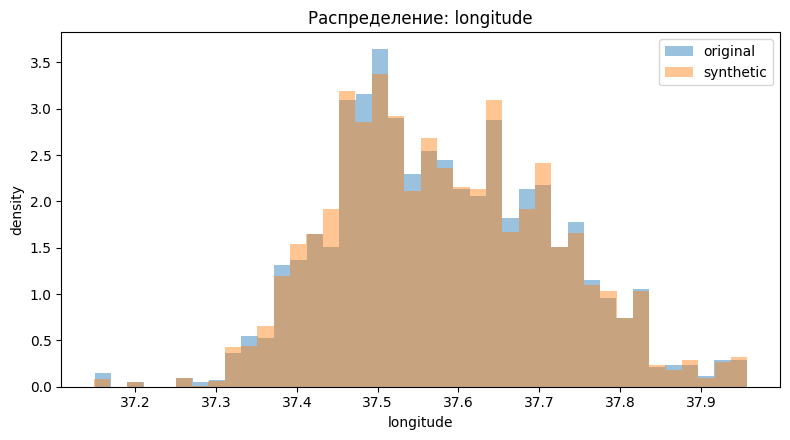

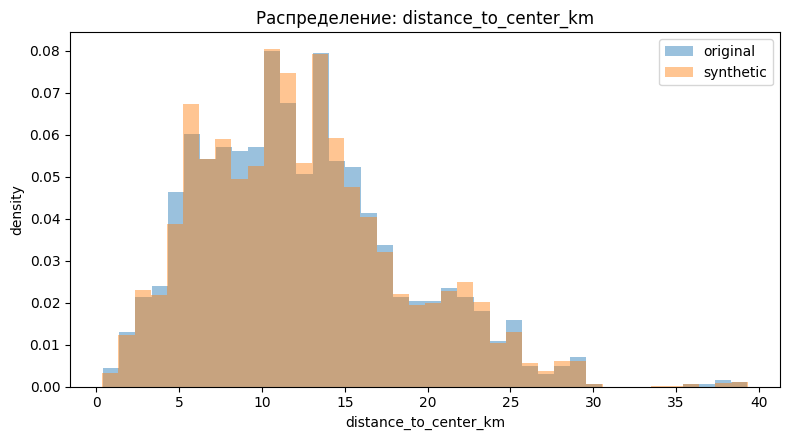

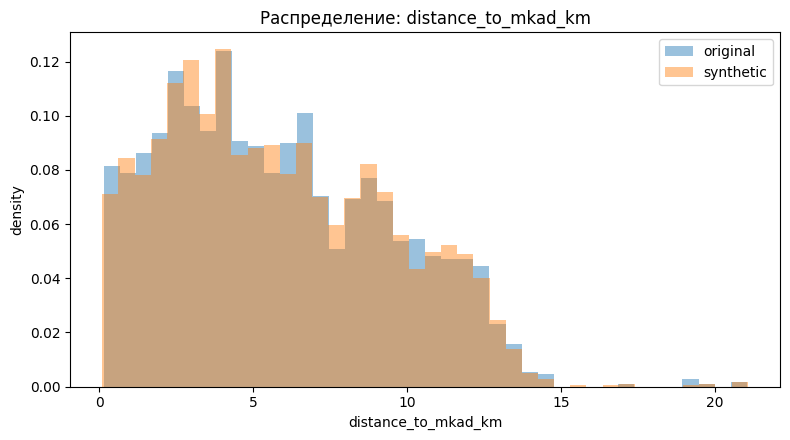

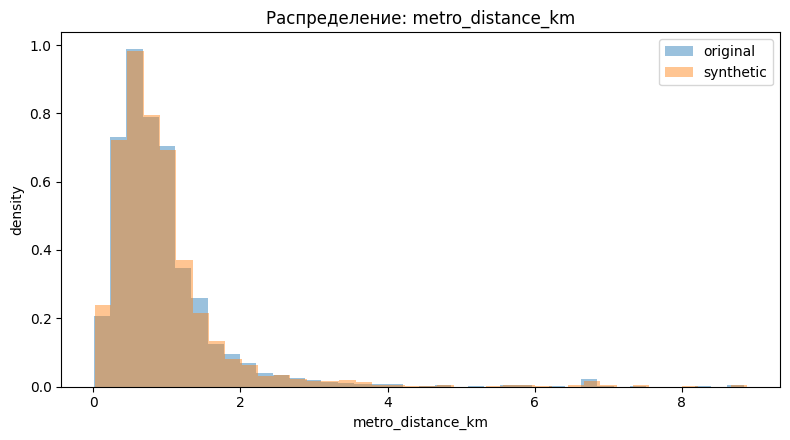

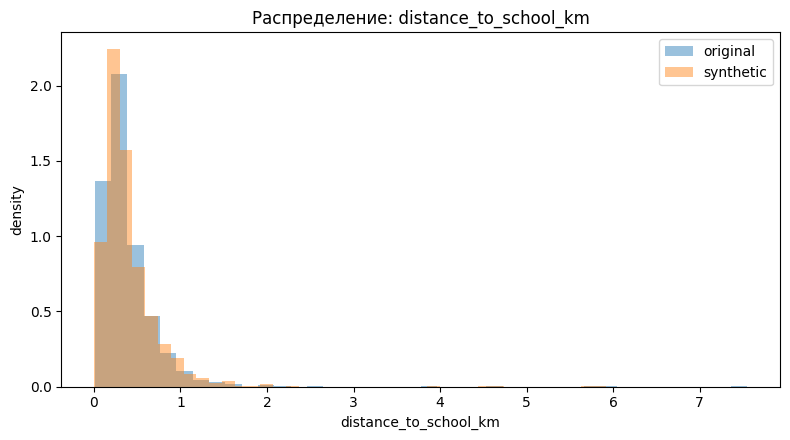

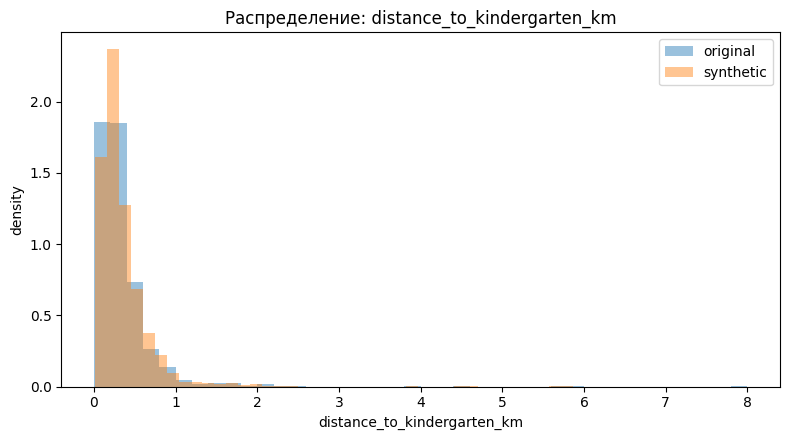

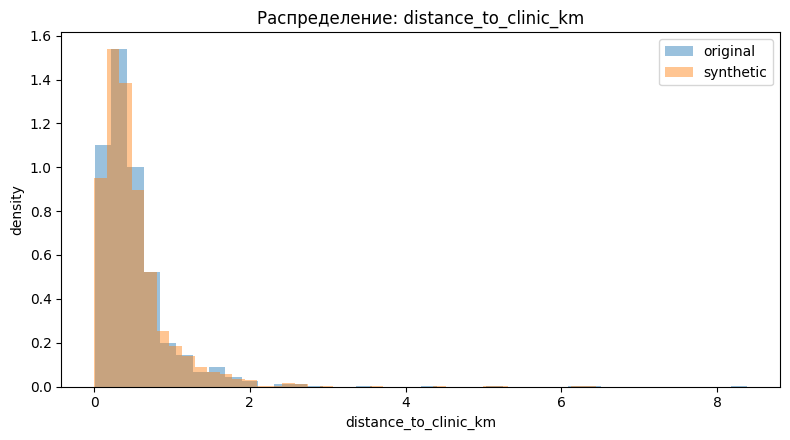

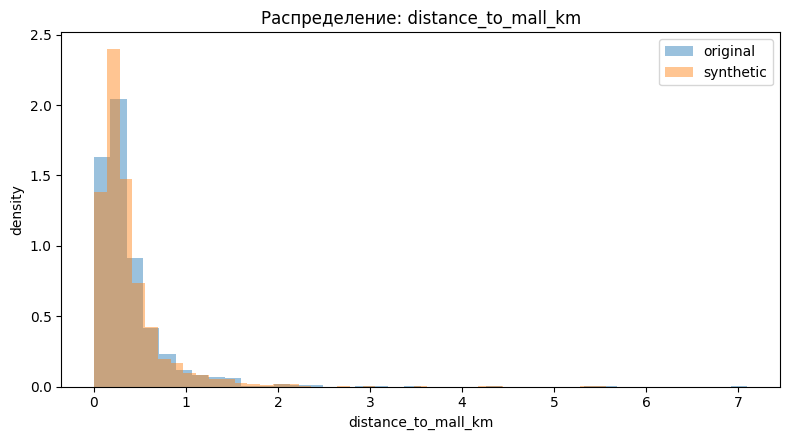

In [91]:
for col in ["latitude", "longitude", "distance_to_center_km", "distance_to_mkad_km", "metro_distance_km",
            "distance_to_school_km", "distance_to_kindergarten_km", "distance_to_clinic_km", "distance_to_mall_km"]:
    if col in key_numeric:
        plot_hist_compare(col)

## 8. Boxplot по ключевым признакам

Для признаков с большим масштабом (`price`, `price_per_m2`) используется `log1p`, чтобы хвосты не скрывали основную массу объектов.

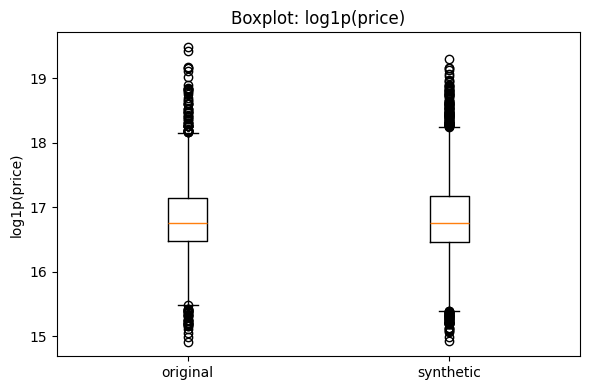

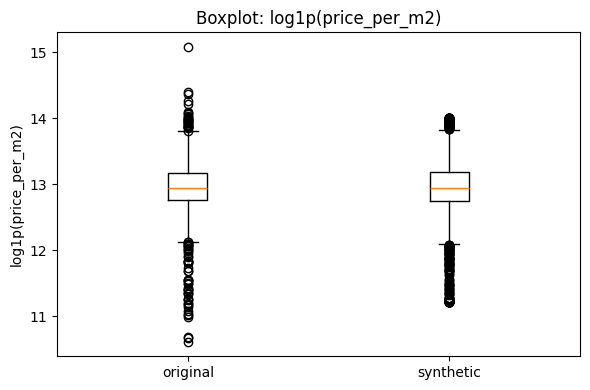

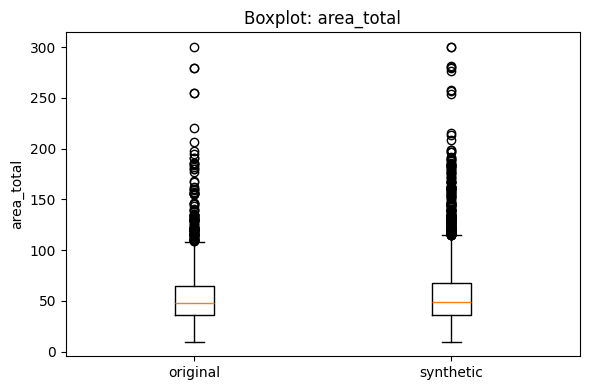

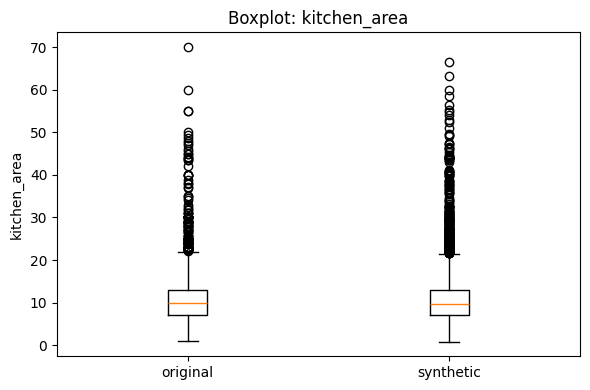

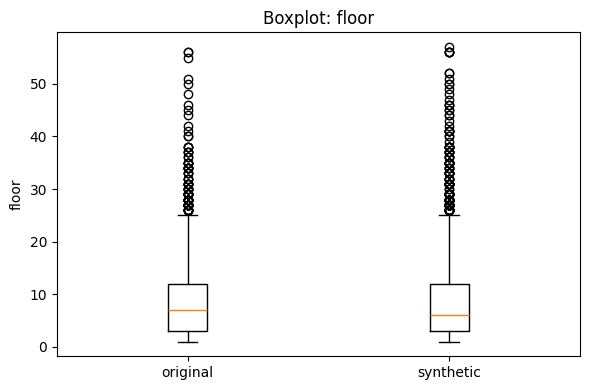

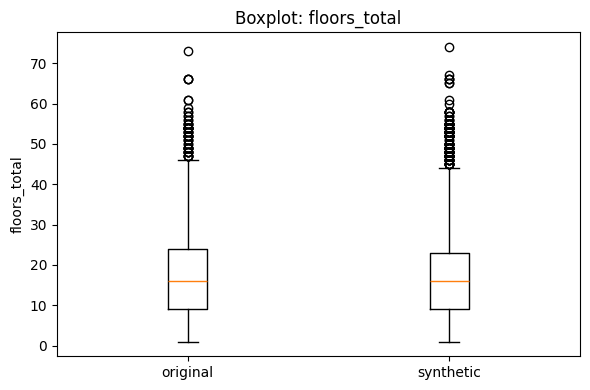

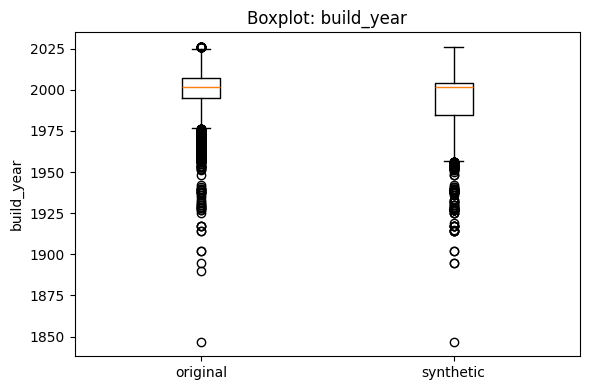

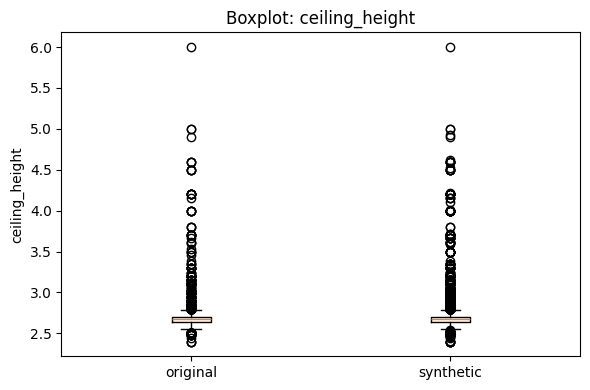

In [92]:
def plot_box_compare(col, log_x=False):
    df = pd.DataFrame({
        "original": orig[col],
        "synthetic": synth[col]
    })
    if log_x:
        df = df.where(df > 0)
        df = np.log1p(df)
        ylabel = f"log1p({col})"
    else:
        ylabel = col

    plt.figure(figsize=(6, 4))
    plt.boxplot([df["original"].dropna(), df["synthetic"].dropna()], labels=["original", "synthetic"], showfliers=True)
    plt.title(f"Boxplot: {ylabel}")
    plt.ylabel(ylabel)
    plt.tight_layout()

for col in ["price", "price_per_m2", "area_total", "kitchen_area", "floor", "floors_total", "build_year", "ceiling_height"]:
    if col in key_numeric:
        plot_box_compare(col, log_x=col in ["price", "price_per_m2"])

## 9. Категориальные признаки

Для категориальных признаков считаем:

- `tvd` — total variation distance между распределениями категорий; 0 = полное совпадение, 1 = полное различие;
- `chi2_pvalue` — p-value χ²-теста независимости;
- число уникальных категорий в original и synthetic.

In [93]:
def categorical_distribution_compare(col, top_n=15):
    o = orig[col].fillna("__MISSING__").astype(str)
    s = synth[col].fillna("__MISSING__").astype(str)
    cats = sorted(set(o.unique()) | set(s.unique()))
    o_counts = o.value_counts().reindex(cats, fill_value=0)
    s_counts = s.value_counts().reindex(cats, fill_value=0)
    o_share = o_counts / len(o)
    s_share = s_counts / len(s)
    diff = s_share - o_share
    table = pd.DataFrame({
        "category": cats,
        "original_count": o_counts.values,
        "synthetic_count": s_counts.values,
        "original_%": o_share.values * 100,
        "synthetic_%": s_share.values * 100,
        "delta_pp": diff.values * 100,
    }).sort_values("delta_pp", key=lambda x: x.abs(), ascending=False)
    return table.head(top_n)

cat_rows = []
for col in categorical_cols:
    o = orig[col].fillna("__MISSING__").astype(str)
    s = synth[col].fillna("__MISSING__").astype(str)
    cats = sorted(set(o.unique()) | set(s.unique()))
    o_counts = o.value_counts().reindex(cats, fill_value=0)
    s_counts = s.value_counts().reindex(cats, fill_value=0)
    o_share = o_counts / len(o)
    s_share = s_counts / len(s)
    tvd = 0.5 * np.abs(o_share - s_share).sum()

    # Chi-square может быть нестабилен при слишком большом числе редких категорий, но как сигнал полезен.
    try:
        chi2, p, dof, expected = chi2_contingency(np.vstack([o_counts.values, s_counts.values]))
    except Exception:
        chi2, p, dof = np.nan, np.nan, np.nan

    cat_rows.append({
        "feature": col,
        "original_unique": o.nunique(),
        "synthetic_unique": s.nunique(),
        "tvd": tvd,
        "chi2_pvalue": p,
        "top_original": o.value_counts().head(3).to_dict(),
        "top_synthetic": s.value_counts().head(3).to_dict(),
    })

cat_compare = pd.DataFrame(cat_rows).sort_values("tvd", ascending=False)
cat_compare

,feature,original_unique,synthetic_unique,tvd,chi2_pvalue,top_original,top_synthetic
9,address_source,2,1,0.8457,0.0000,"{'raw': 1749, 'geo': 319}",{'geo': 4136}
1,metro,287,293,0.1013,1.0000,"{'Потапово': 39, 'Аминьевская': 38, 'Бульвар Р...","{'Потапово': 77, 'Аминьевская': 74, 'Щелковска..."
0,source_group,111,111,0.0343,1.0000,"{'all': 1003, '2k': 208, '1k': 175}","{'all': 1986, '2k': 414, '1k': 356}"
3,walls,46,44,0.0218,0.9997,"{'монолитные': 612, 'панельные': 437, 'кирпичн...","{'монолитные': 1228, 'панельные': 854, 'кирпич..."
2,renovation,17,17,0.0198,0.9969,"{'косметический ремонт': 603, 'евроремонт': 37...","{'косметический ремонт': 1270, 'евроремонт': 7..."
7,parking,43,42,0.0198,1.0000,"{'unknown': 744, 'наземный паркинг': 529, 'наз...","{'unknown': 1448, 'наземный паркинг': 1074, 'н..."
5,elevator,12,12,0.0082,0.9943,"{'unknown': 1154, 'пассажирский, грузовой': 54...","{'unknown': 2296, 'пассажирский, грузовой': 10..."
6,yard,4,4,0.0046,0.9550,"{'двор': 1335, 'unknown': 377, 'детская площад...","{'двор': 2679, 'unknown': 735, 'детская площад..."
8,playground,2,2,0.0031,0.8073,"{'нет': 1589, 'есть': 479}","{'нет': 3165, 'есть': 971}"
4,floor_position,2,2,0.0002,1.0000,"{'не угловая': 2037, 'угловая': 31}","{'не угловая': 4075, 'угловая': 61}"


In [94]:
# Детализация категорий с максимальным отличием
for col in cat_compare["feature"].head(8):
    print("\n" + "="*80)
    print(col)
    display(categorical_distribution_compare(col, top_n=20))


address_source


,category,original_count,synthetic_count,original_%,synthetic_%,delta_pp
0,geo,319,4136,15.4255,100.0000,84.5745
1,raw,1749,0,84.5745,0.0000,-84.5745



metro


,category,original_count,synthetic_count,original_%,synthetic_%,delta_pp
12,Бабушкинская,29,47,1.4023,1.1364,-0.2660
66,ЗИЛ,18,25,0.8704,0.6044,-0.2660
173,Павшино,10,9,0.4836,0.2176,-0.2660
220,Серп и Молот,6,1,0.2901,0.0242,-0.2660
289,Щукинская,8,26,0.3868,0.6286,0.2418
204,Раменки,10,11,0.4836,0.2660,-0.2176
287,Щелковская,27,63,1.3056,1.5232,0.2176
54,Давыдково,4,17,0.1934,0.4110,0.2176
44,Волгоградский проспект,16,41,0.7737,0.9913,0.2176
29,Братиславская,6,20,0.2901,0.4836,0.1934



source_group


...

,category,original_count,synthetic_count,original_%,synthetic_%,delta_pp
0,unknown,744,1448,35.9768,35.0097,-0.9671
35,"подземный паркинг, гостевой паркинг",36,91,1.7408,2.2002,0.4594
10,наземный паркинг,529,1074,25.5803,25.9671,0.3868
12,"наземный паркинг, гостевой паркинг",261,534,12.6209,12.9110,0.2901
37,"подземный паркинг, наземный паркинг",67,143,3.2398,3.4574,0.2176
36,"подземный паркинг, гостевой паркинг, наземный ...",14,22,0.6770,0.5319,-0.1451
18,"наземный паркинг, подземный паркинг",68,130,3.2882,3.1431,-0.1451
13,"наземный паркинг, гостевой паркинг, подземный ...",12,29,0.5803,0.7012,0.1209
19,"наземный паркинг, подземный паркинг, гостевой ...",29,63,1.4023,1.5232,0.1209
2,гостевой паркинг,21,37,1.0155,0.8946,-0.1209



elevator


,category,original_count,synthetic_count,original_%,synthetic_%,delta_pp
1,грузовой,69,153,3.3366,3.6992,0.3627
0,unknown,1154,2296,55.8027,55.5126,-0.2901
6,пассажирский и грузовой,18,27,0.8704,0.6528,-0.2176
9,"пассажирский, грузовой, пассажирский и грузовой",13,33,0.6286,0.7979,0.1692
8,"пассажирский, грузовой",548,1089,26.4990,26.3298,-0.1692
5,пассажирский,172,348,8.3172,8.4139,0.0967
2,"грузовой, пассажирский",55,114,2.6596,2.7563,0.0967
4,"грузовой, пассажирский, пассажирский и грузовой",14,25,0.6770,0.6044,-0.0725
7,"пассажирский и грузовой, пассажирский",5,7,0.2418,0.1692,-0.0725
3,"грузовой, пассажирский и грузовой",7,16,0.3385,0.3868,0.0484



yard


,category,original_count,synthetic_count,original_%,synthetic_%,delta_pp
0,unknown,377,735,18.2302,17.7708,-0.4594
3,парковка,105,220,5.0774,5.3191,0.2418
1,двор,1335,2679,64.5551,64.7727,0.2176
2,детская площадка,251,502,12.1373,12.1373,0.0000


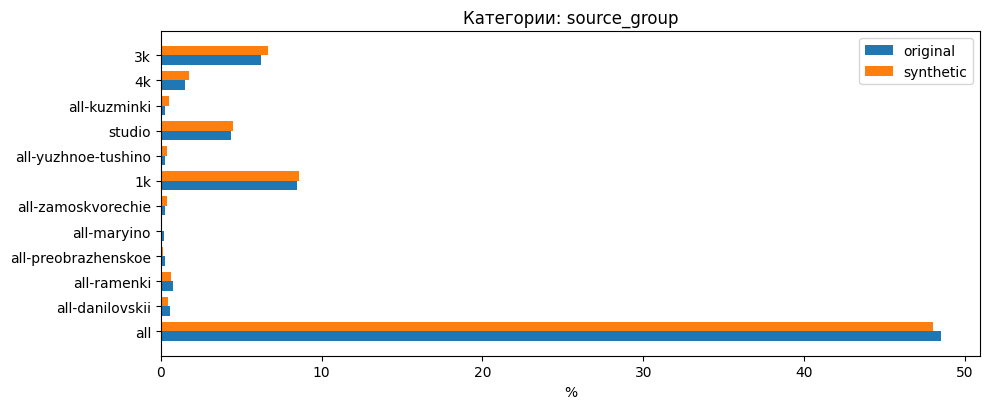

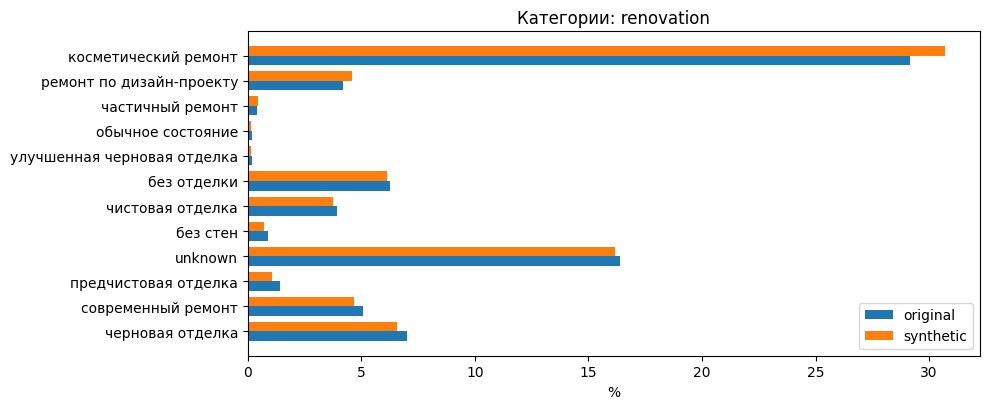

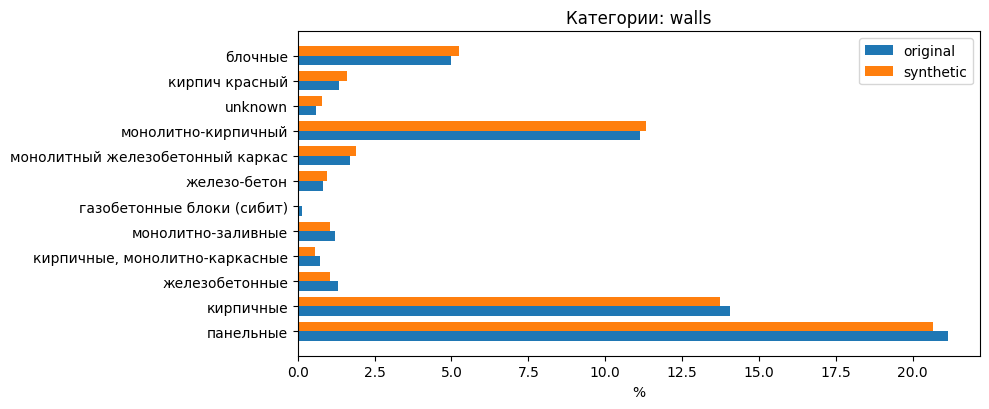

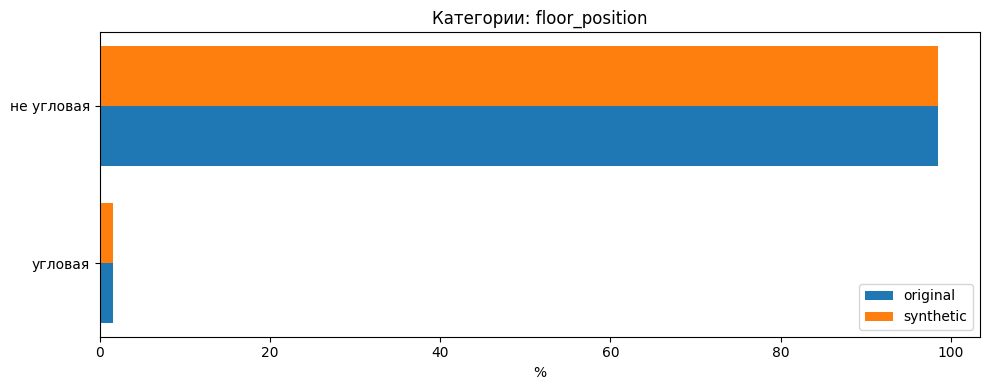

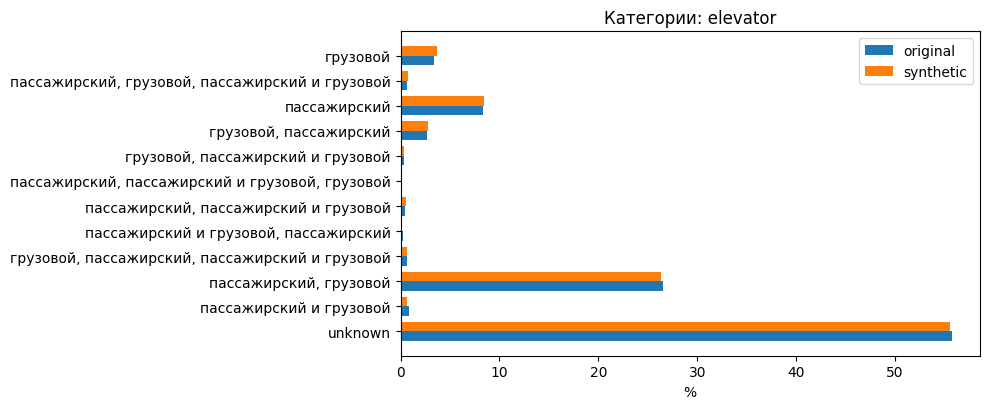

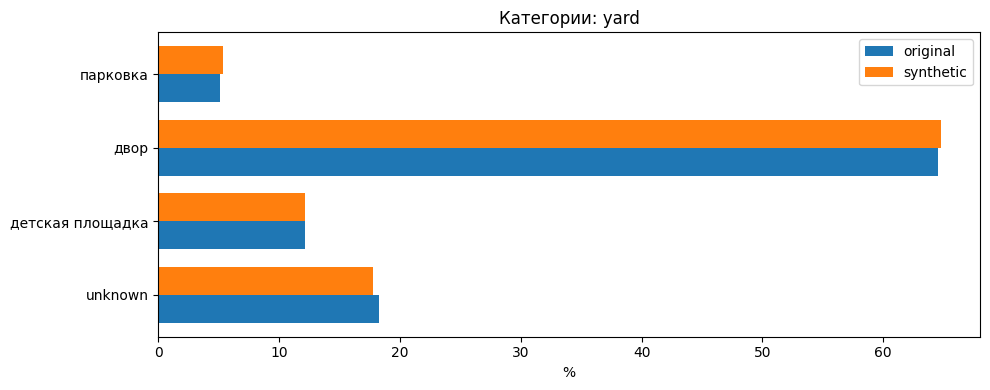

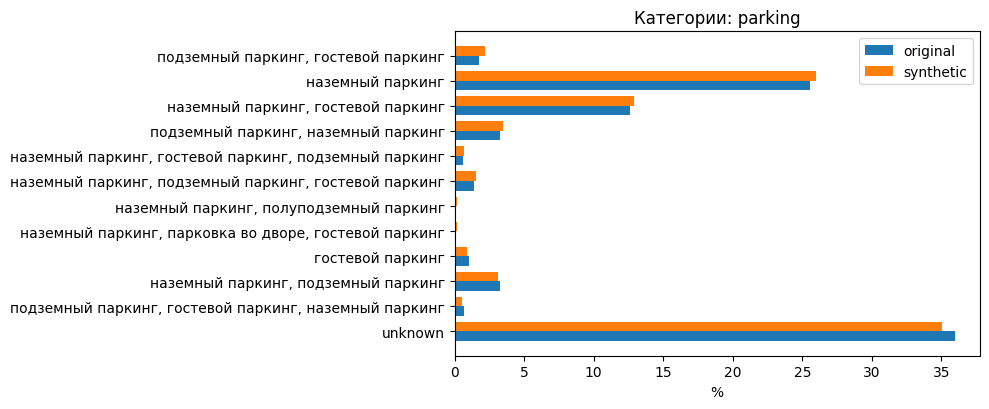

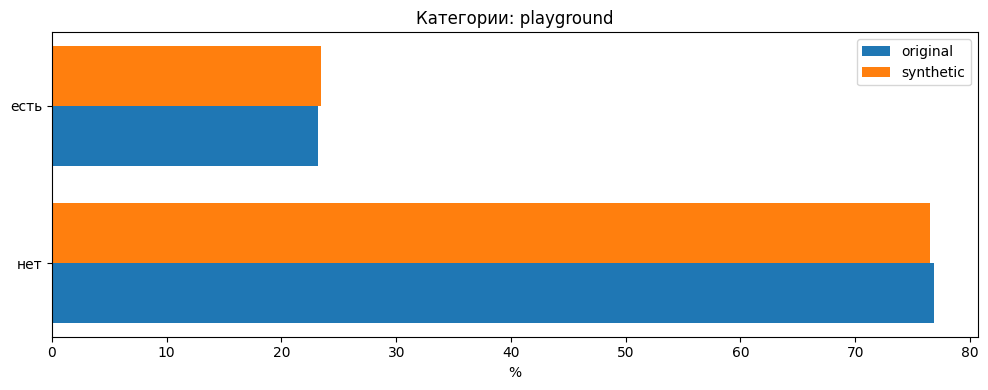

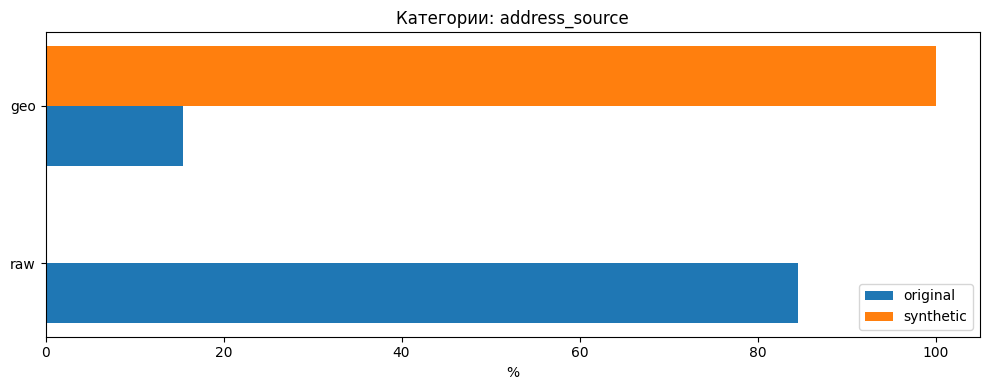

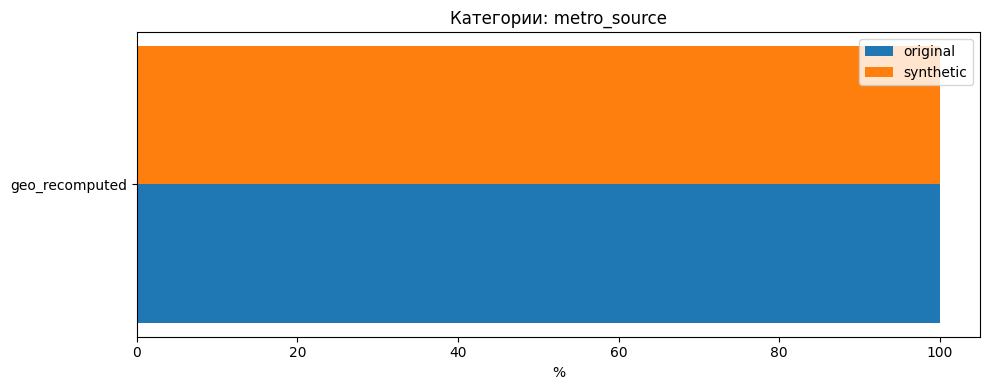

In [95]:
def plot_category_compare(col, top_n=12):
    comp = categorical_distribution_compare(col, top_n=top_n).sort_values("delta_pp")
    labels = comp["category"].astype(str)
    x = np.arange(len(labels))
    width = 0.38

    plt.figure(figsize=(10, max(4, len(labels) * 0.35)))
    plt.barh(x - width/2, comp["original_%"], height=width, label="original")
    plt.barh(x + width/2, comp["synthetic_%"], height=width, label="synthetic")
    plt.yticks(x, labels)
    plt.xlabel("%")
    plt.title(f"Категории: {col}")
    plt.legend()
    plt.tight_layout()

for col in ["source_group", "renovation", "walls", "floor_position", "elevator", "yard", "parking", "playground", "address_source", "metro_source"]:
    if col in categorical_cols:
        plot_category_compare(col)

## 10. Корреляции между числовыми признаками

Даже если распределения по отдельности похожи, синтетика может плохо сохранять связи между признаками: например, цена ↔ площадь, цена за м² ↔ локация, этаж ↔ этажность.

In [96]:
# Берём признаки с достаточным числом ненулевой вариативности
corr_cols = []
for col in numeric_cols:
    if orig[col].nunique(dropna=True) > 3 and synth[col].nunique(dropna=True) > 3:
        corr_cols.append(col)

orig_corr = orig[corr_cols].corr(method="spearman")
synth_corr = synth[corr_cols].corr(method="spearman")
corr_diff = synth_corr - orig_corr

# Топ пар с наибольшим изменением корреляции
pairs = []
for i, c1 in enumerate(corr_cols):
    for c2 in corr_cols[i+1:]:
        pairs.append({
            "feature_1": c1,
            "feature_2": c2,
            "orig_corr": orig_corr.loc[c1, c2],
            "synth_corr": synth_corr.loc[c1, c2],
            "corr_delta": corr_diff.loc[c1, c2],
            "abs_corr_delta": abs(corr_diff.loc[c1, c2]),
        })

corr_pairs = pd.DataFrame(pairs).sort_values("abs_corr_delta", ascending=False)
corr_pairs.head(30)

,feature_1,feature_2,orig_corr,synth_corr,corr_delta,abs_corr_delta
86,floors_total,build_year,0.5154,0.1425,-0.3729,0.3729
97,floors_total,house_age,-0.5154,-0.1425,0.3729,0.3729
148,kitchen_area,build_year,0.3427,0.0496,-0.2931,0.2931
159,kitchen_area,house_age,-0.3427,-0.0496,0.2931,0.2931
79,floor,house_age,-0.3256,-0.0716,0.2540,0.2540
68,floor,build_year,0.3256,0.0716,-0.2540,0.2540
162,build_year,ceiling_height,0.2959,0.0451,-0.2509,0.2509
184,ceiling_height,house_age,-0.2959,-0.0451,0.2509,0.2509
166,build_year,distance_to_school_km,0.3084,0.1141,-0.1944,0.1944
222,distance_to_school_km,house_age,-0.3084,-0.1141,0.1944,0.1944


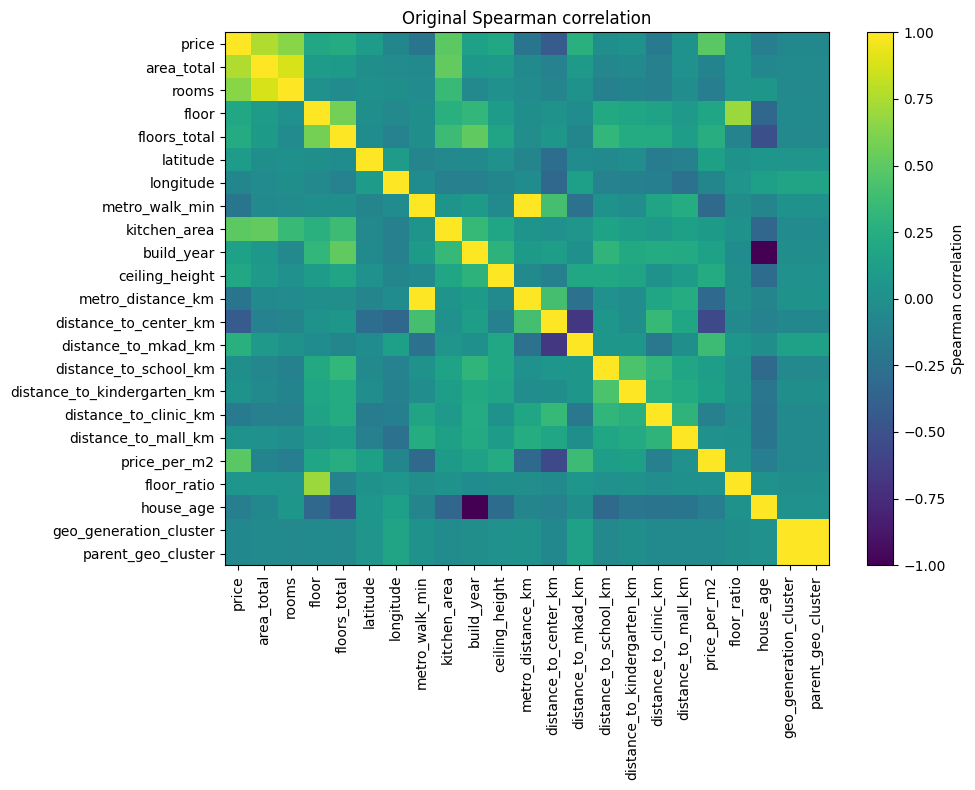

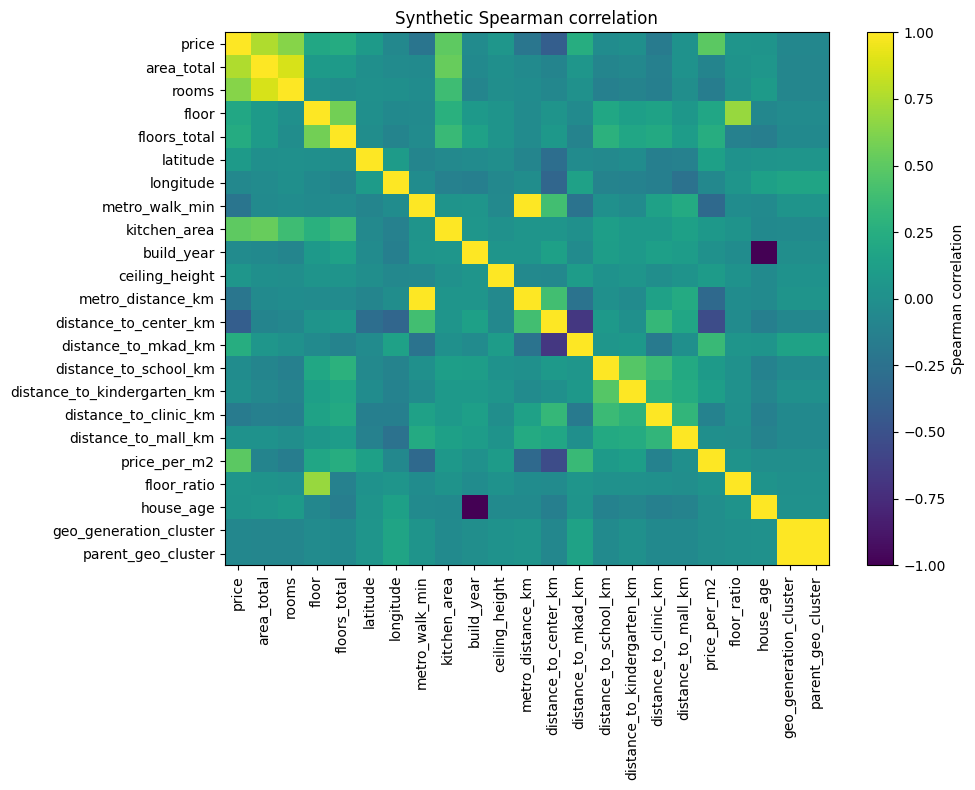

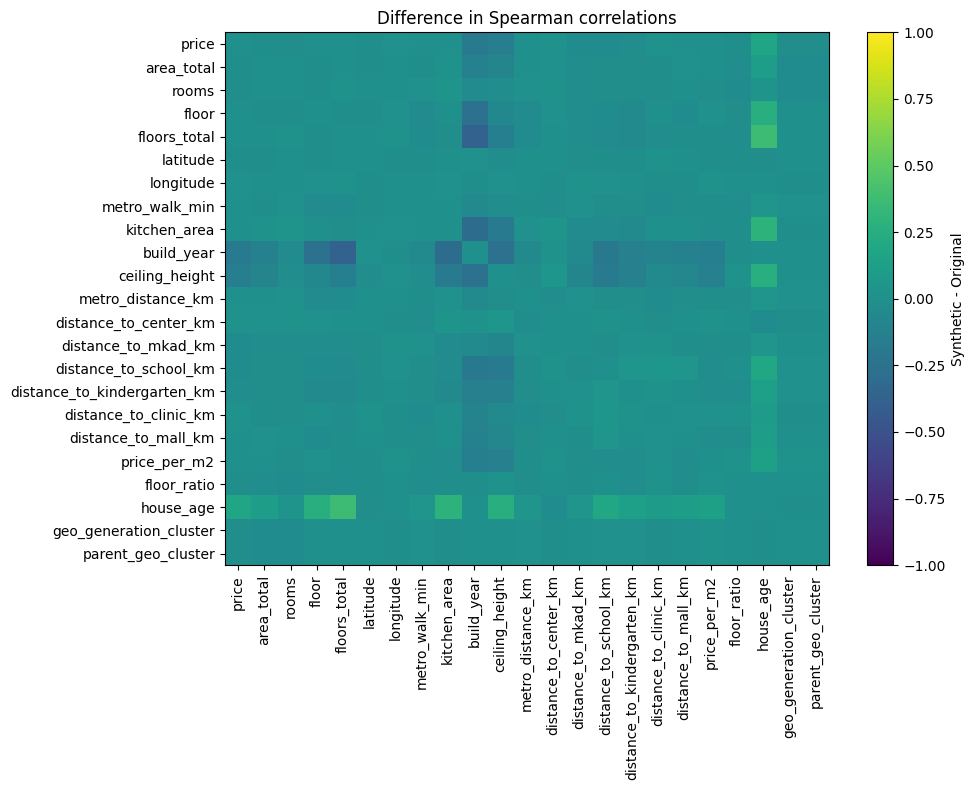

In [97]:
def plot_corr_matrix(matrix, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, aspect="auto", vmin=-1, vmax=1)
    plt.colorbar(label="Spearman correlation")
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
    plt.yticks(range(len(matrix.index)), matrix.index)
    plt.title(title)
    plt.tight_layout()

plot_corr_matrix(orig_corr, "Original Spearman correlation")
plot_corr_matrix(synth_corr, "Synthetic Spearman correlation")

plt.figure(figsize=(10, 8))
plt.imshow(corr_diff, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Synthetic - Original")
plt.xticks(range(len(corr_diff.columns)), corr_diff.columns, rotation=90)
plt.yticks(range(len(corr_diff.index)), corr_diff.index)
plt.title("Difference in Spearman correlations")
plt.tight_layout()

## 11. География

Проверяем, не сместилась ли синтетика пространственно. Для недвижимости это критично: близость к центру, метро, МКАД и инфраструктуре влияет на цену.

In [98]:
geo_cols = [c for c in [
    "latitude", "longitude", "distance_to_center_km", "distance_to_mkad_km", "metro_distance_km",
    "distance_to_school_km", "distance_to_kindergarten_km", "distance_to_clinic_km", "distance_to_mall_km"
] if c in numeric_cols]

num_compare[num_compare["feature"].isin(geo_cols)][[
    "feature", "orig_mean", "synth_mean", "mean_delta_%", "orig_std", "synth_std", "std_delta_%", "ks_stat", "ks_pvalue"
]].sort_values("ks_stat", ascending=False)

,feature,orig_mean,synth_mean,mean_delta_%,orig_std,synth_std,std_delta_%,ks_stat,ks_pvalue
15,distance_to_kindergarten_km,0.3359,0.3502,4.2448,0.3914,0.3669,-6.2657,0.0433,0.0113
14,distance_to_school_km,0.3859,0.3949,2.3309,0.3765,0.3643,-3.2226,0.0210,0.5729
16,distance_to_clinic_km,0.5041,0.5038,-0.0791,0.4990,0.4724,-5.3411,0.0167,0.8355
17,distance_to_mall_km,0.3771,0.3690,-2.1417,0.4175,0.3917,-6.1729,0.0143,0.9405
6,longitude,37.5814,37.5810,-0.0011,0.1348,0.1344,-0.3139,0.0140,0.9480
11,metro_distance_km,0.9533,0.9530,-0.0337,0.8463,0.8556,1.1039,0.0116,0.9921
12,distance_to_center_km,12.4079,12.4123,0.0360,6.1053,6.0614,-0.7184,0.0116,0.9921
5,latitude,55.7312,55.7315,0.0007,0.0943,0.0944,0.0309,0.0099,0.9992
13,distance_to_mkad_km,5.8608,5.8344,-0.4491,3.6176,3.5735,-1.2188,0.0092,0.9998


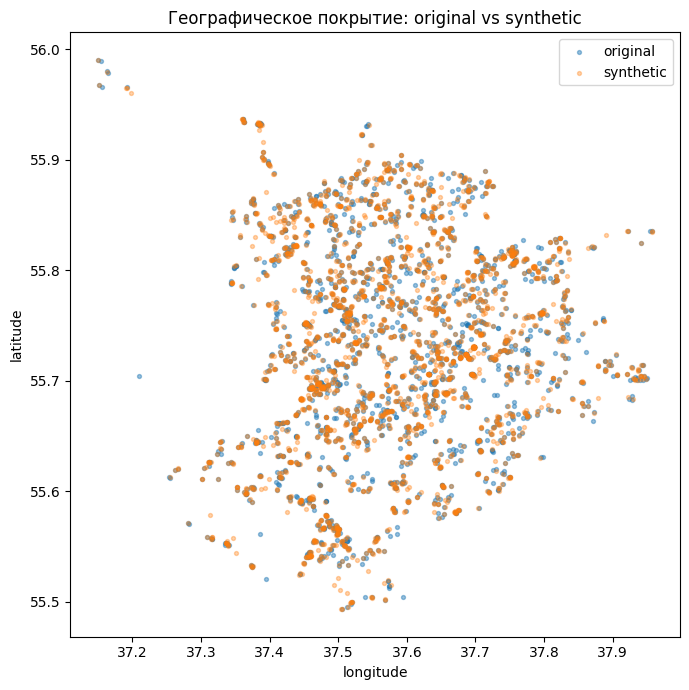

In [99]:
if {"latitude", "longitude"}.issubset(set(orig.columns)):
    plt.figure(figsize=(7, 7))
    sample_o = orig.sample(min(len(orig), 2500), random_state=RANDOM_STATE)
    sample_s = synth.sample(min(len(synth), 2500), random_state=RANDOM_STATE)
    plt.scatter(sample_o["longitude"], sample_o["latitude"], s=8, alpha=0.45, label="original")
    plt.scatter(sample_s["longitude"], sample_s["latitude"], s=8, alpha=0.35, label="synthetic")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title("Географическое покрытие: original vs synthetic")
    plt.legend()
    plt.tight_layout()

## 12. Дубли и пересечения

Проверяем:

- точные дубли внутри оригинала;
- точные дубли внутри синтетики;
- полные совпадения синтетических строк с оригинальными;
- совпадения по содержательным признакам без технических колонок.

In [100]:
content_cols = [c for c in common_cols if c not in {"is_synthetic", "generation_method", "link", "house_age",}]

# Для сравнения приводим типы к строковому представлению, чтобы избежать проблем int/float/object.
def normalize_for_duplicates(df, cols):
    out = df[cols].copy()
    for c in cols:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(8)
        else:
            out[c] = out[c].astype(str).fillna("__MISSING__")
    return out

dup_report = {
    "exact_duplicates_in_original": int(orig.duplicated().sum()),
    "exact_duplicates_in_synthetic": int(synth.duplicated().sum()),
    "content_duplicates_in_original": int(normalize_for_duplicates(orig, content_cols).duplicated().sum()),
    "content_duplicates_in_synthetic": int(normalize_for_duplicates(synth, content_cols).duplicated().sum()),
}

combined_norm = pd.concat([
    normalize_for_duplicates(orig, content_cols).assign(_dataset="original"),
    normalize_for_duplicates(synth, content_cols).assign(_dataset="synthetic"),
], ignore_index=True)

# Сколько синтетических строк полностью совпадают с какой-либо оригинальной по content_cols
orig_keys = set(map(tuple, normalize_for_duplicates(orig, content_cols).to_numpy()))
synth_keys = list(map(tuple, normalize_for_duplicates(synth, content_cols).to_numpy()))
dup_report["synthetic_rows_matching_original_content"] = int(sum(k in orig_keys for k in synth_keys))

dup_report

{'exact_duplicates_in_original': 0,
 'exact_duplicates_in_synthetic': 0,
 'content_duplicates_in_original': 0,
 'content_duplicates_in_synthetic': 0,
 'synthetic_rows_matching_original_content': 0}

## 13. Бизнес-правила и физическая правдоподобность

Эти проверки помогают найти синтетические объекты, которые могут выглядеть статистически нормально, но нарушать смысловые ограничения.

In [101]:
def rule_share(df, condition):
    cond = condition(df)
    return cond.mean() * 100

rules = []

def add_rule(name, condition):
    rules.append({
        "rule": name,
        "original_valid_%": rule_share(orig, condition),
        "synthetic_valid_%": rule_share(synth, condition),
    })

if {"floor", "floors_total"}.issubset(common_cols):
    add_rule("floor <= floors_total", lambda d: d["floor"].isna() | d["floors_total"].isna() | (d["floor"] <= d["floors_total"]))
if {"area_total", "kitchen_area"}.issubset(common_cols):
    add_rule("kitchen_area <= area_total", lambda d: d["kitchen_area"].isna() | d["area_total"].isna() | (d["kitchen_area"] <= d["area_total"]))
if "price" in common_cols:
    add_rule("price > 0", lambda d: d["price"].isna() | (d["price"] > 0))
if "area_total" in common_cols:
    add_rule("area_total > 0", lambda d: d["area_total"].isna() | (d["area_total"] > 0))
if "price_per_m2" in common_cols:
    add_rule("price_per_m2 > 0", lambda d: d["price_per_m2"].isna() | (d["price_per_m2"] > 0))
if "ceiling_height" in common_cols:
    add_rule("2.0 <= ceiling_height <= 5.5", lambda d: d["ceiling_height"].isna() | d["ceiling_height"].between(2.0, 5.5))
if "build_year" in common_cols:
    add_rule("1800 <= build_year <= 2026", lambda d: d["build_year"].isna() | d["build_year"].between(1800, 2026))
if {"latitude", "longitude"}.issubset(common_cols):
    add_rule("Moscow-like coordinates", lambda d: d["latitude"].isna() | d["longitude"].isna() | (d["latitude"].between(54, 57) & d["longitude"].between(35, 39)))

rules_df = pd.DataFrame(rules)
rules_df["delta_pp"] = rules_df["synthetic_valid_%"] - rules_df["original_valid_%"]
rules_df

,rule,original_valid_%,synthetic_valid_%,delta_pp
0,floor <= floors_total,100.0000,100.0000,0.0000
1,kitchen_area <= area_total,100.0000,100.0000,0.0000
2,price > 0,100.0000,100.0000,0.0000
3,area_total > 0,100.0000,100.0000,0.0000
4,price_per_m2 > 0,100.0000,100.0000,0.0000
5,2.0 <= ceiling_height <= 5.5,99.9516,99.9758,0.0242
6,1800 <= build_year <= 2026,100.0000,100.0000,0.0000
7,Moscow-like coordinates,100.0000,100.0000,0.0000


In [102]:
# Проверка согласованности price_per_m2 ~= price / area_total
if {"price", "area_total", "price_per_m2"}.issubset(common_cols):
    def ppm2_error(df):
        mask = (df["price"] > 0) & (df["area_total"] > 0) & (df["price_per_m2"] > 0)
        expected = df.loc[mask, "price"] / df.loc[mask, "area_total"]
        err = (df.loc[mask, "price_per_m2"] - expected).abs() / expected
        return err

    ppm2 = pd.DataFrame({
        "original": ppm2_error(orig).describe(percentiles=[.5, .9, .95, .99]),
        "synthetic": ppm2_error(synth).describe(percentiles=[.5, .9, .95, .99]),
    })
    display(ppm2)
else:
    print("Нет нужных колонок для проверки price_per_m2.")

,original,synthetic
count,"2,068.0000","4,136.0000"
mean,0.0000,0.0000
std,0.0000,0.0000
min,0.0000,0.0000
50%,0.0000,0.0000
90%,0.0000,0.0000
95%,0.0000,0.0000
99%,0.0000,0.0000
max,0.0000,0.0000


## 14. Two-sample classifier test

Идея: обучаем модель отличать оригинальные объекты от синтетических.

Интерпретация:

- ROC-AUC около **0.5** — синтетика трудноотличима от оригинала;
- ROC-AUC **0.7–0.8** — отличия заметные;
- ROC-AUC **0.9+** — синтетика легко распознаётся, качество имитации слабое.

Это не заменяет EDA, но даёт сильный общий сигнал.

In [103]:
compare_features = [
    "price",
    "price_per_m2",
    "area_total",
    "kitchen_area",
    "rooms",
    "floor",
    "floors_total",
    "ceiling_height",
    "build_year",
    "distance_to_center_km",
    "distance_to_mkad_km",
    "metro_distance_km",
    "distance_to_school_km",
    "distance_to_kindergarten_km",
    "distance_to_clinic_km",
    "distance_to_mall_km",
    "latitude",
    "longitude"
]


In [104]:
model_cols = [c for c in compare_features if c not in {"is_synthetic", "generation_method", "link", "address", "house_number"}]

X = pd.concat([orig[model_cols], synth[model_cols]], ignore_index=True)
y = np.r_[np.zeros(len(orig)), np.ones(len(synth))]

num_model_cols = [c for c in model_cols if pd.api.types.is_numeric_dtype(X[c])]
cat_model_cols = [c for c in model_cols if c not in num_model_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_model_cols),
    ("cat", categorical_pipe, cat_model_cols),
])

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

print("CV ROC-AUC scores:", np.round(auc_scores, 4))
print("Mean ROC-AUC:", round(auc_scores.mean(), 4))
print("Std ROC-AUC:", round(auc_scores.std(), 4))

CV ROC-AUC scores: [0.4949 0.4977 0.5123]
Mean ROC-AUC: 0.5017
Std ROC-AUC: 0.0076


In [105]:
# Финальная train/test проверка и признаки, которые сильнее всего помогают отличить синтетику
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
pred_proba = clf.predict_proba(X_test)[:, 1]
pred = (pred_proba >= 0.5).astype(int)

print("Holdout ROC-AUC:", round(roc_auc_score(y_test, pred_proba), 4))
print("\nClassification report:")
print(classification_report(y_test, pred, target_names=["original", "synthetic"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

# Feature importance для логистической регрессии по абсолютному коэффициенту
prep = clf.named_steps["prep"]
model = clf.named_steps["model"]

feature_names = []
feature_names.extend(num_model_cols)
if cat_model_cols:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    feature_names.extend(ohe.get_feature_names_out(cat_model_cols).tolist())

coef = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_[0],
})
coef["abs_coef"] = coef["coef"].abs()
coef.sort_values("abs_coef", ascending=False).head(30)

Holdout ROC-AUC: 0.4986

Classification report:
              precision    recall  f1-score   support

    original       0.34      0.49      0.40       517
   synthetic       0.67      0.53      0.59      1034

    accuracy                           0.51      1551
   macro avg       0.51      0.51      0.50      1551
weighted avg       0.56      0.51      0.53      1551

Confusion matrix:
[[254 263]
 [491 543]]


,feature,coef,abs_coef
2,area_total,0.1059,0.1059
13,distance_to_kindergarten_km,0.0969,0.0969
0,price,-0.0865,0.0865
15,distance_to_mall_km,-0.0793,0.0793
1,price_per_m2,0.0755,0.0755
9,distance_to_center_km,0.0563,0.0563
11,metro_distance_km,-0.0476,0.0476
12,distance_to_school_km,0.0431,0.0431
4,rooms,0.0337,0.0337
6,floors_total,-0.0335,0.0335


## 15. Автоматический итоговый отчёт

Ниже формируется короткое резюме на основе рассчитанных метрик.

In [106]:
summary = {}
summary["n_original"] = len(orig)
summary["n_synthetic"] = len(synth)
summary["ratio"] = len(synth) / len(orig)
summary["same_schema"] = orig_cols == synth_cols
summary["numeric_features"] = len(numeric_cols)
summary["categorical_features"] = len(categorical_cols)
summary["ks_significant_count"] = int((num_compare["ks_pvalue"] < 0.05).sum())
summary["ks_significant_share_%"] = float((num_compare["ks_pvalue"] < 0.05).mean() * 100)
summary["median_abs_mean_delta_%"] = float(num_compare["mean_delta_%"].abs().median())
summary["median_std_delta_%"] = float(num_compare["std_delta_%"].median())
summary["features_std_shrunk_10pct_count"] = int((num_compare["std_delta_%"] < -10).sum())
summary["max_cat_tvd"] = float(cat_compare["tvd"].max()) if len(cat_compare) else np.nan
summary["worst_cat_feature"] = cat_compare.iloc[0]["feature"] if len(cat_compare) else None
summary["auc_mean"] = float(auc_scores.mean())
summary["auc_std"] = float(auc_scores.std())

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
summary_df

,value
n_original,2068
n_synthetic,4136
ratio,2.0000
same_schema,True
numeric_features,24
categorical_features,11
ks_significant_count,4
ks_significant_share_%,16.6667
median_abs_mean_delta_%,0.4030
median_std_delta_%,-0.5551


In [107]:
print("ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ")
print("-" * 80)
print(f"Оригинальный train: {summary['n_original']} строк; синтетика: {summary['n_synthetic']} строк; отношение: {summary['ratio']:.2f}x.")
print(f"Схема колонок совпадает: {summary['same_schema']}.")
print(f"Числовых признаков для сравнения: {summary['numeric_features']}; категориальных: {summary['categorical_features']}.")
print(f"Доля числовых признаков с p-value KS < 0.05: {summary['ks_significant_share_%']:.1f}%.")
print(f"Медианное абсолютное отклонение средних: {summary['median_abs_mean_delta_%']:.2f}%.")
print(f"Медианное изменение стандартного отклонения synthetic vs original: {summary['median_std_delta_%']:.2f}%.")
print(f"Число признаков, где std синтетики ниже оригинала более чем на 10%: {summary['features_std_shrunk_10pct_count']}.")
print(f"Максимальное отличие категориальных распределений TVD: {summary['max_cat_tvd']:.3f}; признак: {summary['worst_cat_feature']}.")
print(f"Two-sample classifier ROC-AUC: {summary['auc_mean']:.3f} ± {summary['auc_std']:.3f}.")

print("\nКак читать результат:")
if summary['auc_mean'] < 0.6:
    print("Модель почти не отличает синтетику от оригинала: это хороший общий сигнал.")
elif summary['auc_mean'] < 0.75:
    print("Модель отличает синтетику умеренно: синтетика похожа, но содержит заметные артефакты.")
else:
    print("Модель хорошо отличает синтетику от оригинала: стоит искать артефакты генерации и пересмотреть метод аугментации.")

if summary['median_std_delta_%'] < -5:
    print("Есть признак сжатия распределений: синтетика менее вариативна, чем оригинал.")
else:
    print("Сильного общего сжатия распределений по std не видно.")

ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ
--------------------------------------------------------------------------------
Оригинальный train: 2068 строк; синтетика: 4136 строк; отношение: 2.00x.
Схема колонок совпадает: True.
Числовых признаков для сравнения: 24; категориальных: 11.
Доля числовых признаков с p-value KS < 0.05: 16.7%.
Медианное абсолютное отклонение средних: 0.40%.
Медианное изменение стандартного отклонения synthetic vs original: -0.56%.
Число признаков, где std синтетики ниже оригинала более чем на 10%: 0.
Максимальное отличие категориальных распределений TVD: 0.846; признак: address_source.
Two-sample classifier ROC-AUC: 0.502 ± 0.008.

Как читать результат:
Модель почти не отличает синтетику от оригинала: это хороший общий сигнал.
Сильного общего сжатия распределений по std не видно.
